# The Hopf oscillator model

The Hopf model describes the complex-plane motion of membrane potentials x and y of a single neuronal population (or local brain area) with a pair of mutually coupled linear–nonlinear differential equations: when the bifurcation parameter a is negative the origin is a stable focus and the population remains silent, whereas for a>0 the origin loses stability and a limit cycle emerges, so the population oscillates persistently at frequency ω.

In [1]:
import brainmass
import brainstate
import braintools
import brainunit as u
import jax
import matplotlib.pyplot as plt
import numpy as np

In [2]:
brainstate.environ.set(dt=0.1 * u.ms)

## Single node simulation

The normal-form (supercritical) Hopf oscillator for a single node can be written in complex form as

$$
\frac{dz}{dt} = (a + i\,\omega) z - \beta \lvert z \rvert^2 z + I_{\text{ext}}(t),
$$

where $z = x + i y$ and $\lvert z \rvert^2 = x^2 + y^2$. In real coordinates $(x, y)$ this becomes

$$
\begin{aligned}
\dot x &= (a - \beta r) x - \omega y + I_x(t),\\
\dot y &= (a - \beta r) y + \omega x + I_y(t),\\
 r &= x^2 + y^2.
\end{aligned}
$$


### Parameters

| Parameter | Symbol | Role | Typical Range |
|-----------|--------|------|---------------|
| Bifurcation | $a$ | Controls proximity to oscillation onset | -1 to 1 |
| Frequency | $\omega$ | Angular frequency of oscillation | 0.1 to 1.0 |
| Saturation | $\beta$ | Limits oscillation amplitude | > 0 |

For $a > 0$, the limit cycle has radius $\approx \sqrt{a/\beta}$.


In [3]:
node = brainmass.HopfStep(
    1,  # single node
    a=0.25,
    w=0.2,
    beta=1.0,
    noise_x=brainmass.OUProcess(1, sigma=0.01),
    noise_y=brainmass.OUProcess(1, sigma=0.01),
)
node.init_all_states()


def step_run(i):
    node.update()
    return node.x.value, node.y.value


indices = np.arange(10000)
x_trace, y_trace = brainstate.transform.for_loop(step_run, indices)

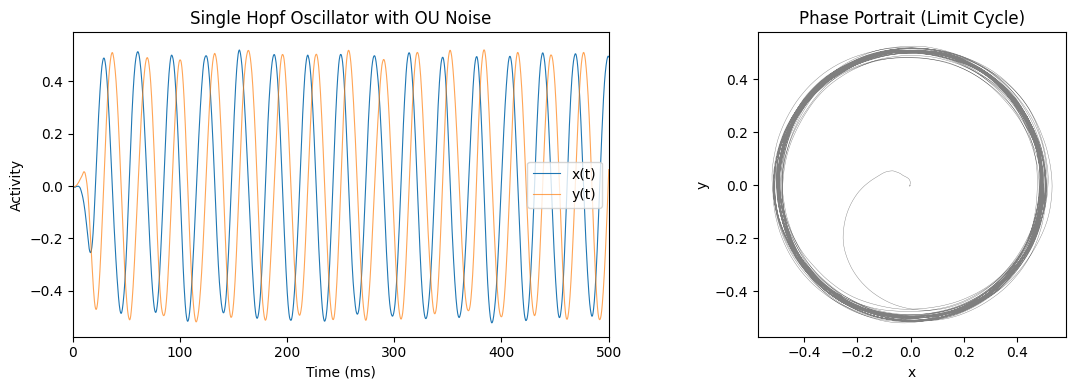

In [4]:
t_ms = indices * brainstate.environ.get_dt()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Time series
axes[0].plot(t_ms, x_trace[:, 0], label='x(t)', linewidth=0.8)
axes[0].plot(t_ms, y_trace[:, 0], label='y(t)', linewidth=0.8, alpha=0.7)
axes[0].set_xlabel('Time (ms)')
axes[0].set_ylabel('Activity')
axes[0].set_title('Single Hopf Oscillator with OU Noise')
axes[0].legend()
axes[0].set_xlim([0, 500])

# Phase portrait
axes[1].plot(x_trace[:, 0], y_trace[:, 0], 'k-', linewidth=0.3, alpha=0.5)
axes[1].set_xlabel('x')
axes[1].set_ylabel('y')
axes[1].set_title('Phase Portrait (Limit Cycle)')
axes[1].set_aspect('equal')

plt.tight_layout()
plt.show()

## Bifurcation diagram

At the origin $(x,y)=(0,0)$ the linearization has eigenvalues $\lambda_{\pm} = a \pm i \omega$.

- For $a < 0$: the origin is a stable focus; trajectories spiral into $(0,0)$.
- For $a = 0$: a Hopf bifurcation occurs.
- For $a > 0$: the origin is unstable and a stable limit cycle of radius $\approx \sqrt{a/\beta}$ emerges (supercritical Hopf). The oscillation frequency is approximately $\omega$ near onset.

Increasing $\beta$ decreases the saturated amplitude while leaving the linear frequency set by $\omega$.


In [5]:
a_vals = np.linspace(-2, 2, 500)  # 500 points

nodes = brainmass.HopfStep(
    a_vals.size,
    a=a_vals,  # 每个节点对应一个 a
    w=0.2,
    beta=1.0,
    init_x=braintools.init.Uniform(0, 1),
    init_y=braintools.init.Uniform(0, 1),
)
nodes.init_all_states()


def step_run(i):
    return nodes.update()


indices = np.arange(20000)
x_trace = brainstate.transform.for_loop(step_run, indices)[0]
x_last = x_trace[-5000:]  # shape (5000, 50)
max_x = x_last.max(axis=0)
min_x = x_last.min(axis=0)

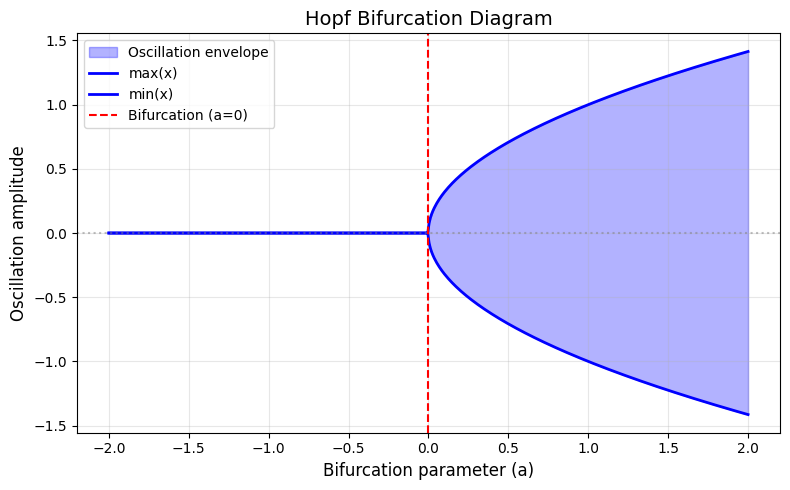

In [6]:
plt.figure(figsize=(8, 5))
plt.fill_between(a_vals, min_x, max_x, alpha=0.3, color='blue', label='Oscillation envelope')
plt.plot(a_vals, max_x, 'b-', lw=2, label='max(x)')
plt.plot(a_vals, min_x, 'b-', lw=2, label='min(x)')
plt.axvline(0.0, ls='--', color='red', label='Bifurcation (a=0)')
plt.axhline(0.0, ls=':', color='gray', alpha=0.5)

plt.xlabel('Bifurcation parameter (a)', fontsize=12)
plt.ylabel('Oscillation amplitude', fontsize=12)
plt.title('Hopf Bifurcation Diagram', fontsize=14)
plt.legend(loc='upper left')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Brain network with diffusive coupling

For $N$ nodes with states $(x_i, y_i)$ one convenient diffusive coupling is

$$
\begin{aligned}
\dot x_i &= (a - \beta r_i) x_i - \omega y_i \; + \; K \sum_{j} W_{ij} (x_j - x_i) + I_i^x(t),\\
\dot y_i &= (a - \beta r_i) y_i + \omega x_i \; + \; K \sum_{j} W_{ij} (y_j - y_i) + I_i^y(t),\\
 r_i &= x_i^2 + y_i^2,
\end{aligned}
$$

where $W$ is a connectivity matrix and $K$ a global coupling gain. In BrainMass this can be assembled using the coupling helpers (`DiffusiveCoupling` or `diffusive_coupling`) by prefetching node states and applying the kernel per component.

An alternative is to couple in the complex form, $z_i = x_i + i y_i$, using a linear term $K \sum_j W_{ij} (z_j - z_i)$; real and imaginary parts yield the two equations above.

Relation to Kuramoto: In the limit of strongly attracting amplitudes (large $\beta$ and $a>0$), the dynamics reduce approximately to phase-only coupling (Kuramoto-type) on the emergent limit cycle.


Load the human connectome project sample data from Kaggle.

In [7]:
import os.path
import kagglehub

path = kagglehub.dataset_download("oujago/hcp-gw-data-samples")
data = braintools.file.msgpack_load(os.path.join(path, "hcp-data-sample.msgpack"))


print(f"Connectome shape: {data['Cmat'].shape}")
print(f"Distance matrix shape: {data['Dmat'].shape}")

Loading checkpoint from D:\Data\kagglehub\datasets\oujago\hcp-gw-data-samples\versions\1\hcp-data-sample.msgpack
Connectome shape: (80, 80)
Distance matrix shape: (80, 80)


In [8]:
class Network(brainstate.nn.Module):
    def __init__(self, signal_speed=2.):
        super().__init__()

        # connection weight
        conn_weight = data['Cmat'].copy()
        np.fill_diagonal(conn_weight, 0)
        self.conn_weight = conn_weight

        # delay information
        delay_time = data['Dmat'].copy() / signal_speed
        np.fill_diagonal(delay_time, 0)
        delay_time = delay_time * u.ms
        indices_ = np.repeat(
            np.expand_dims(np.arange(conn_weight.shape[1]), 0),
            conn_weight.shape[0],
            axis=0
        )
        delay_index = (delay_time, indices_)

        # nodes
        n_node = conn_weight.shape[1]
        self.n_node = n_node
        self.node = brainmass.HopfStep(
            n_node,
            w=1.0,
            a=0.25,
            init_x=braintools.init.Uniform(0, 0.5),
            init_y=braintools.init.Uniform(0, 0.5),
            noise_x=brainmass.OUProcess(n_node, sigma=0.14, tau=5.0 * u.ms),
            noise_y=brainmass.OUProcess(n_node, sigma=0.14, tau=5.0 * u.ms),
        )

        # couplings
        self.coupling_x = brainmass.DiffusiveCoupling(
            self.node.prefetch_delay('x', delay_index, init=braintools.init.Uniform(0, 0.05)),
            self.node.prefetch('x'),
            conn_weight,
            k=1.0
        )

    def update(self):
        self.node.update(x_inp=self.coupling_x())
        return self.node.x.value, self.node.y.value

    def step_run(self, i):
        return self.update()

In [9]:
# Run the simulation
net = Network()
net.init_all_states()
dt = brainstate.environ.get_dt()
indices = np.arange(0, int(0.5 * u.second // dt))

exes_tuple = brainstate.transform.for_loop(net.step_run, indices)
exes_x = jax.block_until_ready(exes_tuple[0])
exes_y = jax.block_until_ready(exes_tuple[1])

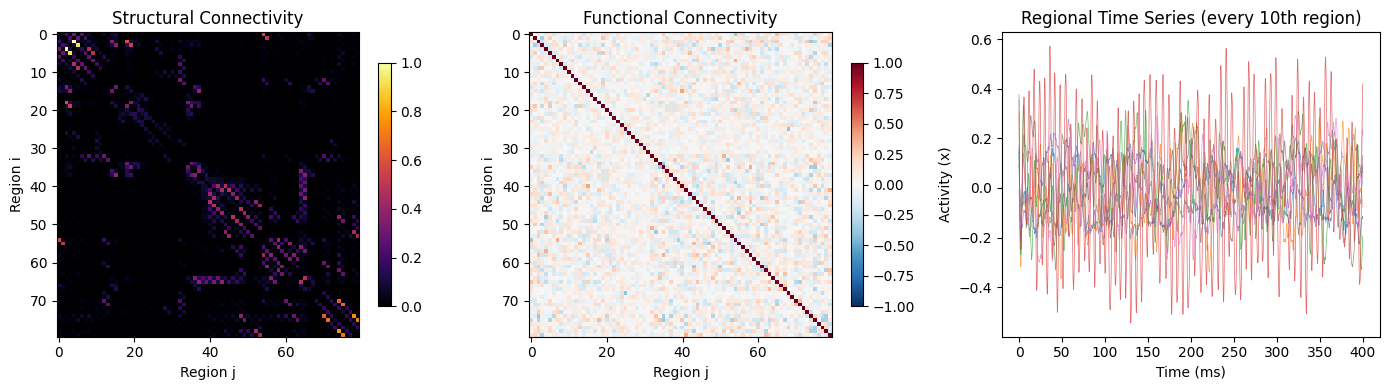

In [10]:
plt.rcParams['image.cmap'] = 'inferno'

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

# Structural connectivity
im0 = axes[0].imshow(net.conn_weight, aspect='auto')
axes[0].set_title('Structural Connectivity')
axes[0].set_xlabel('Region j')
axes[0].set_ylabel('Region i')
plt.colorbar(im0, ax=axes[0], shrink=0.8)

# Functional connectivity (from simulated data)
fc = braintools.metric.functional_connectivity(exes_x)
im1 = axes[1].imshow(fc, aspect='auto', vmin=-1, vmax=1, cmap='RdBu_r')
axes[1].set_title('Functional Connectivity')
axes[1].set_xlabel('Region j')
axes[1].set_ylabel('Region i')
plt.colorbar(im1, ax=axes[1], shrink=0.8)

# Time series of selected regions
t_ms = indices * dt
axes[2].plot(t_ms, exes_x[:, ::10], alpha=0.7, linewidth=0.5)
axes[2].set_xlabel('Time (ms)')
axes[2].set_ylabel('Activity (x)')
axes[2].set_title('Regional Time Series (every 10th region)')

plt.tight_layout()
plt.show()

## Exercises

### Exercise 1: Frequency Analysis

The oscillation frequency depends on both $\omega$ and the coupling. Modify the network to use different $\omega$ values and observe:
1. How does the dominant frequency change?
2. How does coupling affect frequency?

*Hint*: Use `np.fft.fft` to compute the power spectrum.

### Exercise 2: Coupling Strength

Explore different coupling strengths:
```python
for k in [0.1, 1.0, 5.0, 10.0]:
    net = HopfNetwork(coupling_strength=k)
    # Run and analyze...
```

Questions:
1. What happens at very weak coupling?
2. What happens at very strong coupling?
3. How does functional connectivity change with coupling strength?

### Exercise 3: Subcritical Regime

Set `a=-0.1` (below bifurcation) and observe how noise can induce oscillations even in the subcritical regime. This demonstrates **noise-induced oscillations**.

## References

1. Deco, G., Kringelbach, M. L., Jirsa, V. K., & Ritter, P. (2017). The dynamics of resting fluctuations in the brain: metastability and its dynamical cortical core. *Scientific Reports*, 7(1), 3095.

2. Kuznetsov, Y. A. (2013). *Elements of applied bifurcation theory* (Vol. 112). Springer Science & Business Media.

3. Deco, G., et al. (2009). Key role of coupling, delay, and noise in resting brain fluctuations. *PNAS*, 106(25), 10302-10307.